In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ../../..

/Users/dave/Library/CloudStorage/OneDrive-PolitecnicodiMilano/PhD/Repositories/DT-rse


## Evaluate Experiment Results

In this notebook, we test the adaptation phase of the OL routine with an offline dataset generated by the estimation routine. The idea is to validate the method and create a new faulty cluster from the outlier set.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import seaborn as sns
from pathlib import Path
from scipy import signal
import plotly.graph_objects as go
from IPython.display import display, clear_output
import time

from ernesto.postprocessing.visualization import ernesto_plotter
from ernesto.adaptation.regime_shift.stats import *

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Set the basic style
# 'paper' context sets the base font size small (approx 8-9pt). 
# Scaling it by 1.3-1.5 usually matches standard 11pt/12pt thesis text nicely.
sns.set_context("paper", font_scale=1.4) 

# 2. Define the visual style
sns.set_style('whitegrid', {
    'grid.linestyle': '--', 
    'grid.alpha': 0.5,          # Lower alpha for less intrusive grid
    'grid.color': '.8',
    'axes.edgecolor': '0.15',
    'font.family': 'serif',     # Matches LaTeX default
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
})

# 3. Fine-tune Matplotlib params for Publication Quality
plt.rcParams.update({
    # Figure Size: 6x3.7 is close to the Golden Ratio for A4/Letter width
    'figure.figsize': (6.0, 3.75), 
    
    # Line width: Thicker for the main mean line
    'lines.linewidth': 2.0,     
    
    # Fonts: Ensure math looks like LaTeX
    'mathtext.fontset': 'cm',   # 'cm' = Computer Modern (LaTeX standard)
    'mathtext.rm': 'serif',
    
    # Axes and Ticks
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.bottom': True,       # Ensure ticks are visible
    'ytick.left': True,
    
    # Legend: Clean and readable
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fancybox': False,   # Square corners match academic style better
    'legend.edgecolor': '0.8',
})

# 4. Color Palette: High contrast, colorblind safe
# Using 'bright' or 'colorblind' is best for distinguishing RL agents
plot_colors = sns.color_palette("colorblind")

Evolving clustering (not working!): 
- batch_size 5000
- ks 0.01
- minOutlier 30
- lambda 0.8

Evolving clustering (ok -> 1 faulty cluster): 
- batch_size 6000
- ks 0.01
- minOutlier 10
- lambda 0.8

Evolving clustering (ok -> too many faults (8)): 
- batch_size 1500
- ks 0.01
- minOutlier 30
- lambda 0.8

Evolving clustering (ok -> some faults (4)): 
- batch_size 1500
- ks 0.01
- minOutlier 30
- lambda 0.95

Evolving clustering (ok -> just 1 fault): 
- batch_size 3000
- ks 0.01
- minOutlier 30
- lambda 0.95

In [4]:
exp_type = 'single' #'single' or 'multi'
is_validation = True

if is_validation:
    #folder = f"data/output/adaptive/phdThesis/region_shift_validation/"
    folder = f"data/output/adaptive/phdThesis/prova_validation/"
else:
    #folder = f"data/output/adaptive/phdThesis/region_{exp_type}_shift_experiment/routine_with_noise/"
    folder = f"data/output/adaptive/phdThesis/region_{exp_type}_shift_experiment/extrapolation/"


plot_folder = folder + 'plots/'
os.makedirs(plot_folder, exist_ok=True)

folder_adaptive = folder + 'evolving-clustering-3000-30out-095lambda-noscale'
#folder_adaptive = folder + 'evolving-clustering-3000-30out-095lambda'

path_adaptive = Path(folder_adaptive)

In [5]:
samples_file = 'parameter_evolution.csv'
ground_file = 'ground_0.csv'
sim_datasets = [f for f in os.listdir(path_adaptive) if f.startswith('dataset')]
clust_files = [f for f in os.listdir(path_adaptive) if f.startswith('cluster')]

df_samples = pd.read_csv(path_adaptive / samples_file)
df_ground = pd.read_csv(path_adaptive / ground_file)
sorted(sim_datasets)
df_sim = pd.concat((pd.read_csv(path_adaptive / f) for f in sorted(sim_datasets)), ignore_index=True)
dfs_clusters = {clust_file.split('cluster_')[1].split('.')[0]: pd.read_csv(path_adaptive / clust_file) for clust_file in clust_files}

#dfs_clusters['nominal'] = dfs_clusters.pop('cluster_nominal_temp_40.csv')
#dfs_clusters['faulty1'] = dfs_clusters.pop('cluster_faulty_1.csv')

In [6]:
folder_passive = folder + 'passive-adaptation/'
path_passive = Path(folder_passive)

samples_file = 'parameter_evolution.csv'
passive_datasets = [f for f in os.listdir(path_passive) if f.startswith('dataset')]
sorted(passive_datasets)
df_passive = pd.read_csv(path_passive / samples_file)
df_sim_passive = pd.concat((pd.read_csv(path_passive / f) for f in sorted(passive_datasets)), ignore_index=True)

In [9]:
#folder_clushift = folder + 'cluster-shift/'
#path_clushift = Path(folder_clushift)

#samples_file = 'parameter_evolution.csv'
#clushift_datasets = [f for f in os.listdir(path_clushift) if f.startswith('dataset')]
#sorted(clushift_datasets)
#df_clushift = pd.read_csv(path_clushift / samples_file)
#df_sim_clushift = pd.concat((pd.read_csv(path_clushift / f) for f in sorted(clushift_datasets)), ignore_index=True)

In [10]:
if is_validation:
    df_real = df_ground
else:
    folder_real = folder + 'real_params/'
    path_real = Path(folder_real)

    real_datasets = [f for f in os.listdir(path_real) if f.startswith('dataset')]
    sorted(real_datasets)
    df_real = pd.concat((pd.read_csv(path_real / f) for f in sorted(real_datasets)), ignore_index=True)

In [11]:
#folder_fixed = "data/output/adaptive/"
folder_fixed = folder + 'fixed_params'
#folder_fixed = folder_fixed + 'region_shift_experiment/test_complete_routine/fixed_params/'
#folder_fixed = folder_fixed + 'region_multiple_shift_experiment/test_complete_routine/fixed_params/'
#folder_fixed = folder_fixed + 'region_shift_experiment/test_complete_routine/validation_fixed_params/'
#folder_fixed = folder_fixed + 'region_shift_experiment/test_complete_routine/validation_real_params/'
path_fixed = Path(folder_fixed)

In [12]:
fixed_datasets = [f for f in os.listdir(path_fixed) if f.startswith('dataset')]
sorted(fixed_datasets)
df_fixed = pd.concat((pd.read_csv(path_fixed / f) for f in sorted(fixed_datasets)), ignore_index=True)

FileNotFoundError: [Errno 2] No such file or directory: 'data/output/adaptive/phdThesis/prova_validation/fixed_params'

In [13]:
df_real

,current,voltage,t_amb,time,soc,temperature
0,-19.9866,3.89722,313.2103,0,0.700000,313.210000
1,-19.9778,3.89431,313.1658,1,0.699722,313.210936
2,-19.9778,3.89243,313.1578,2,0.699445,313.208734
3,-19.9778,3.89085,313.1903,3,0.699167,313.206133
4,-19.9778,3.88942,313.1831,4,0.698890,313.205956
...,...,...,...,...,...,...
899994,-19.9787,3.46484,283.6886,899994,0.347484,283.716562
899995,-19.9786,3.46474,283.6694,899995,0.347206,283.720301
899996,-19.9786,3.46462,283.6742,899996,0.346929,283.722457
899997,-19.9786,3.46451,283.6418,899997,0.346651,283.724796


In [14]:
df_fixed

NameError: name 'df_fixed' is not defined

In [15]:
df_sim_passive

,time,soc,soh,c_max,voltage,current,power,v_oc,r0,r1,c1,v_r0,v_rc,i_r1,i_c,temperature,heat,t_amb,dVoc_dT
0,-1,0.700000,1.0,20.0,3.897220,0.0000,0.000000,0.000000,0.001830,0.002069,26290.432970,0.000000,0.000000,0.000000,0.000000,313.210000,0.000000,313.2103,-0.000002
1,0,0.699722,1.0,20.0,3.812887,19.9866,-76.206657,3.850209,0.001830,0.002069,26290.432970,0.036575,0.000746,0.360802,19.625798,313.210845,0.731289,313.2103,-0.000002
2,1,0.699445,1.0,20.0,3.811912,19.9778,-76.153624,3.849951,0.001830,0.002069,26290.432970,0.036559,0.001479,0.714932,19.262868,313.208558,0.731433,313.1658,-0.000002
3,2,0.699167,1.0,20.0,3.810934,19.9778,-76.134070,3.849692,0.001830,0.002069,26290.432970,0.036559,0.002199,1.062669,18.915131,313.205877,0.732712,313.1578,-0.000001
4,3,0.698890,1.0,20.0,3.809968,19.9778,-76.114774,3.849432,0.001830,0.002069,26290.432970,0.036559,0.002905,1.404129,18.573671,313.205627,0.734455,313.1903,-0.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,899994,0.347206,1.0,20.0,3.368669,19.9787,-67.301626,3.645410,0.005411,0.008899,33218.550881,0.108103,0.168638,18.949583,1.029117,283.726239,5.355371,283.6886,-0.000023
899996,899995,0.346929,1.0,20.0,3.368553,19.9786,-67.298979,3.645324,0.005411,0.008899,33218.550881,0.108102,0.168669,18.953052,1.025548,283.728410,5.356520,283.6694,-0.000023
899997,899996,0.346651,1.0,20.0,3.368437,19.9786,-67.296649,3.645238,0.005411,0.008899,33218.550881,0.108102,0.168699,18.956509,1.022091,283.730764,5.357686,283.6742,-0.000023
899998,899997,0.346374,1.0,20.0,3.368320,19.9786,-67.294323,3.645153,0.005411,0.008899,33218.550881,0.108102,0.168730,18.959955,1.018645,283.730720,5.358849,283.6418,-0.000023


In [16]:
df_samples

,soc,temperature,r0,r1,c1,cluster,is_outlier,time,active_cluster
0,1.000000,303.150000,0.002198,0.002480,22966.778613,nominal_temp_40,False,0,nominal_temp_40
1,0.800000,303.150000,0.002238,0.002910,24140.464793,nominal_temp_40,False,0,nominal_temp_40
2,0.600000,303.150000,0.002271,0.002205,20859.505625,nominal_temp_40,False,0,nominal_temp_40
3,0.500000,303.150000,0.002291,0.002436,22622.611802,nominal_temp_40,False,0,nominal_temp_40
4,0.400000,303.150000,0.002308,0.002862,26234.314231,nominal_temp_40,False,0,nominal_temp_40
...,...,...,...,...,...,...,...,...,...
309,0.439664,283.522290,0.004801,0.008254,24491.529786,faulty_3,False,296,faulty_3
310,0.439565,283.544636,0.004785,0.008259,24491.602718,faulty_3,False,297,faulty_3
311,0.439945,283.533180,0.004767,0.008287,24491.448660,NaN,True,298,faulty_3
312,0.439502,283.535352,0.004793,0.008255,24491.452061,faulty_3,False,299,faulty_3


In [17]:
comparison_params = {
    #'dfs': [df_real[97000:106000], df_sim[97000:106000]], 
    'dfs': [df_real[1:], df_sim[1:]], 
    #'dfs': [df_real[1:-1], df_sim_passive[1:], df_sim[1:], df_sim_clushift[1:]], 
    #'dfs': [df_real, df_sim_passive[1:], df_sim[1:], df_sim_clushift[1:]], 
    'variables': ['voltage'], #'r0', 'r1', 'c1', 'current'], 
    'x_axes': ['time'] * 10,
    #'labels': ['Ground', 'Memoryless Adaptation', 'Evolving Clustering', 'Cluster Shift'],
    'labels': ['Ground', 'Evolving Clustering',],
    'x_labels': ['Time [s]'] * 10,
    'y_labels': ['Voltage [V]', r'$R_0 [\Omega]$', r'$R_1 [\Omega]$', '$C_1 [Ah]$', 'Current [A]'],
    'markers': [''] * 10,
    'line_styles': ['-', '-', '-.', '--'],
    'save_fig': False,
    'sampling_rate': 5000,
    'colors': [plot_colors[0], plot_colors[1], plot_colors[2], plot_colors[4]],
    'plot_type': 'line',
    'dest': Path(folder), 
    'fig_name': f'OL-{exp_type}_tj{'-validation' if is_validation else ''}',
    'pic_format': 'pdf',
    'save_extend_bbox': (1.5,1.5),
    'figsize': (8, 4.5),
    'tick_font_size': 16,
    'label_font_size': 16,
    'legend_font_size': 14,
    'legend_ncol': 2,
    'legend_loc': 'lower left',
    'legend_bbox': (0, 1),
    'alphas':[1] * 5
}

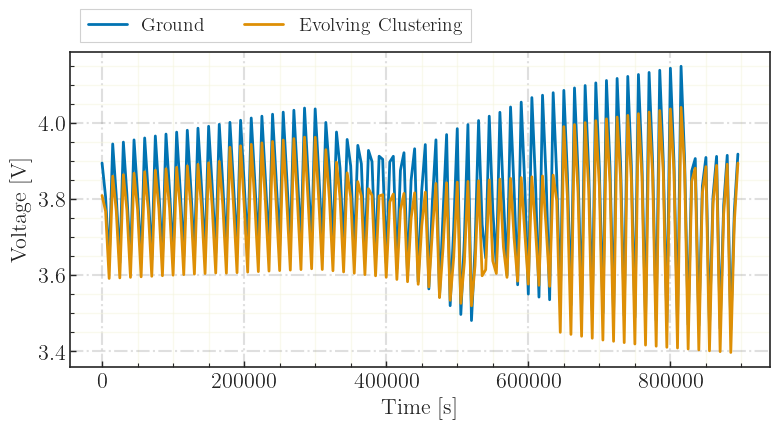

In [18]:
ernesto_plotter(**comparison_params)

In [21]:
zoom_in = {
    'dfs': [df_real[97000:106000], df_sim[97000:106000]], 
    #'dfs': [df_real[1:30000], df_sim[1:]], 
    #'dfs': [df_real[1:-1], df_sim_passive[1:], df_sim[1:], df_sim_clushift[1:]], 
    #'dfs': [df_real, df_sim_passive[1:], df_sim[1:], df_sim_clushift[1:]], 
    'variables': ['voltage', 'current', 't_amb'], #'r0', 'r1', 'c1', 'current'], 
    'x_axes': ['time'] * 10,
    #'labels': ['Ground', 'Memoryless Adaptation', 'Evolving Clustering', 'Cluster Shift'],
    'labels': ['Ground', 'Evolving Clustering',],
    'x_labels': ['Time [s]'] * 10,
    'y_labels': ['Voltage [V]', r'$R_0 [\Omega]$', r'$R_1 [\Omega]$', '$C_1 [Ah]$', 'Current [A]'],
    'markers': [''] * 10,
    'line_styles': ['-', '-', '-.', '--'],
    'save_fig': False,
    'sampling_rate': 1,
    'colors': [plot_colors[0], plot_colors[1], plot_colors[2], plot_colors[4]],
    'plot_type': 'line',
    'dest': Path(folder), 
    'fig_name': f'OL-{exp_type}_tj{'-validation' if is_validation else ''}',
    'pic_format': 'pdf',
    'save_extend_bbox': (1.5,1.5),
    'figsize': (8, 4.5),
    'tick_font_size': 16,
    'label_font_size': 16,
    'legend_font_size': 14,
    'legend_ncol': 2,
    'legend_loc': 'lower left',
    'legend_bbox': (0, 1),
    'alphas':[1] * 5
}

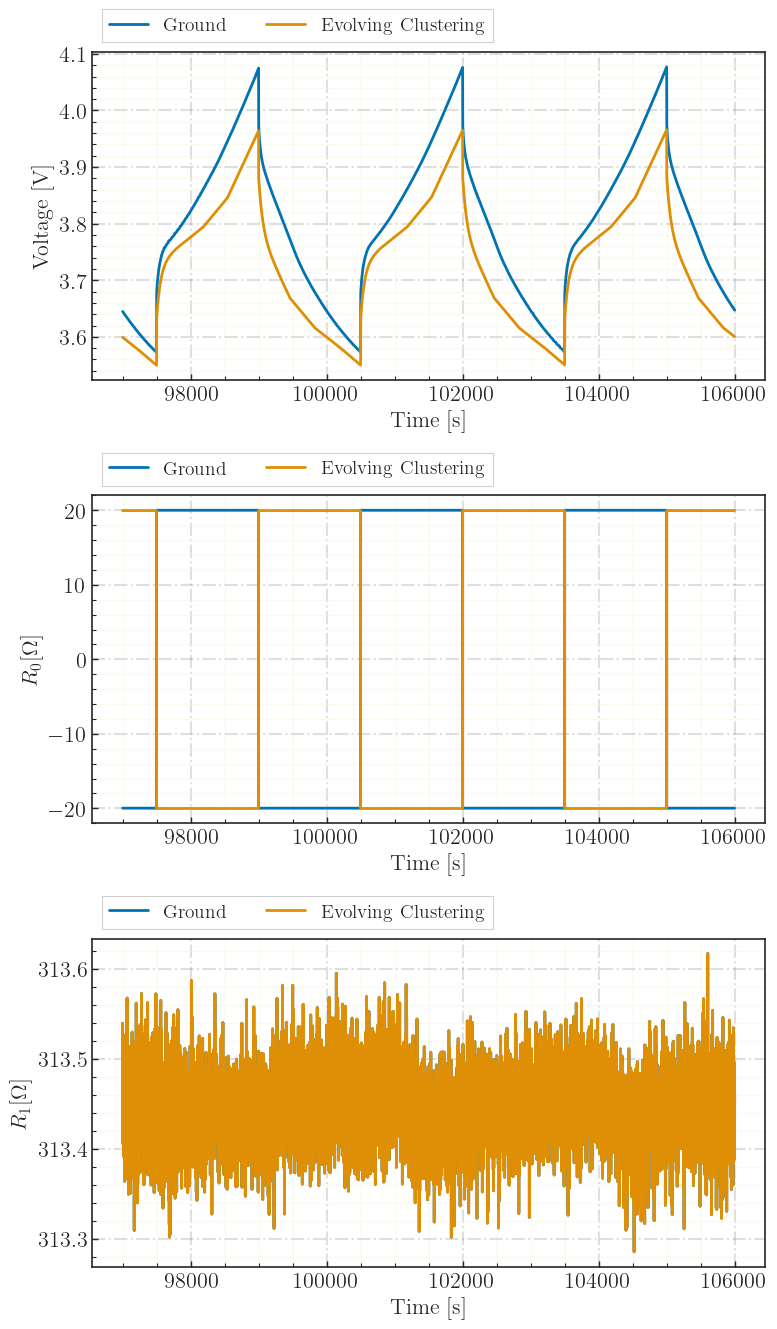

In [22]:
ernesto_plotter(**zoom_in)

In [39]:
single_params = {
    'dfs': [df_sim_passive[500000:700000]], 
    'variables': ['r0', 'r1', 'c1'], 
    'x_axes': ['time'] * 10,
    'labels': ['Memoryless Adaptation', 'Evolving Clustering', 'Cluster Shift'],
    #'labels': ['Ground', 'Evolving Clustering',],
    'x_labels': ['Time [s]'] * 10,
    'y_labels': ['R0', 'R1', 'C1', 'SoC', 'Current', 'Voc'],
    'markers': ['o'] * 10,
    'line_styles': [''],
    'save_fig': False,
    'sampling_rate': 1,
    'colors': [plot_colors[0], plot_colors[1], plot_colors[2], plot_colors[4]],
    'plot_type': 'scatter',
    'dest': Path(folder), 
    'fig_name': f'OL-{exp_type}_tj{'-validation' if is_validation else ''}',
    'pic_format': 'pdf',
    'save_extend_bbox': (1.5,1.5),
    'figsize': (8, 4),
    'tick_font_size': 16,
    'label_font_size': 16,
    'legend_font_size': 14,
    'legend_ncol': 2,
    'legend_loc': 'lower left',
    'legend_bbox': (0, 1),
    'alphas':[1] * 5
}

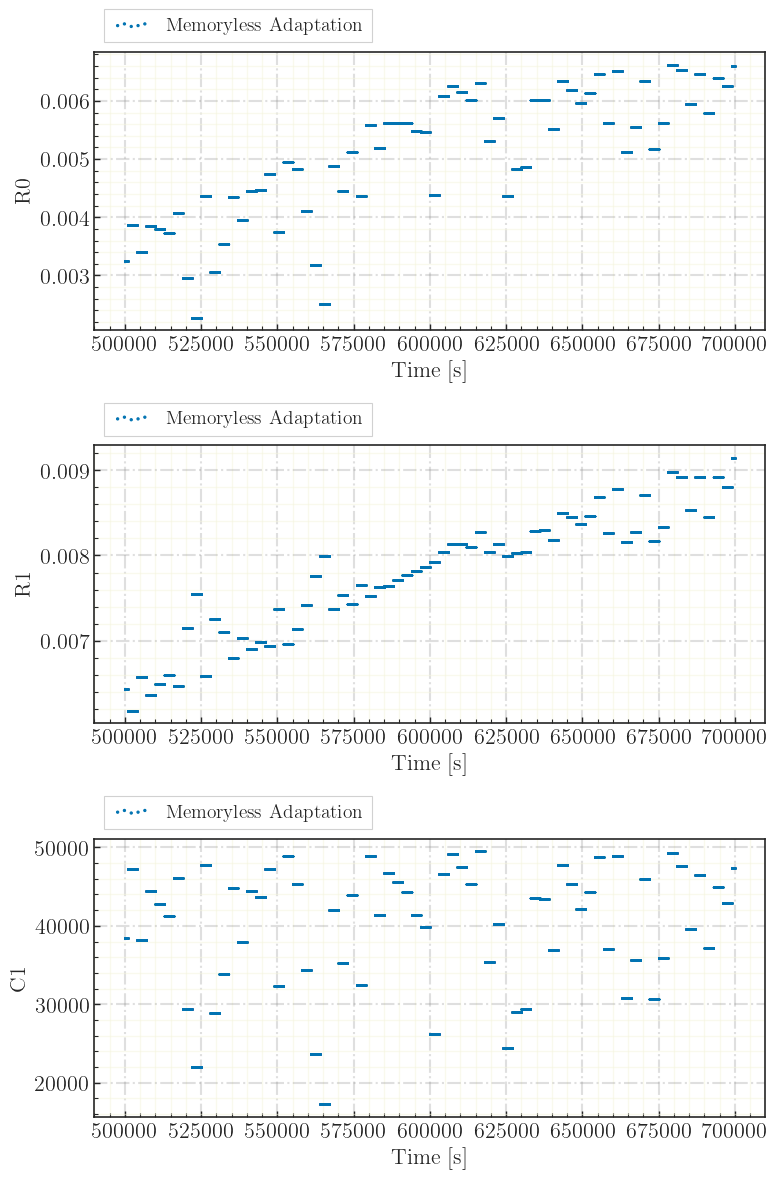

In [40]:
ernesto_plotter(**single_params)

In [27]:
single_params = {
    'dfs': [df_sim_passive[500000:700000]], 
    'variables': ['r0', 'r1', 'c1', 'soc', 'current', 'v_oc'], 
    'x_axes': ['time'] * 10,
    'labels': ['Memoryless Adaptation', 'Evolving Clustering', 'Cluster Shift'],
    #'labels': ['Ground', 'Evolving Clustering',],
    'x_labels': ['Time [s]'] * 10,
    'y_labels': ['SoC', 'Current', 'Voc'],
    'markers': [''] * 10,
    'line_styles': ['-', '-', '-.', '--'],
    'save_fig': False,
    'sampling_rate': 1,
    'colors': [plot_colors[0], plot_colors[1], plot_colors[2], plot_colors[4]],
    'plot_type': 'line',
    'dest': Path(folder), 
    'fig_name': f'OL-{exp_type}_tj{'-validation' if is_validation else ''}',
    'pic_format': 'pdf',
    'save_extend_bbox': (1.5,1.5),
    'figsize': (8, 4),
    'tick_font_size': 16,
    'label_font_size': 16,
    'legend_font_size': 14,
    'legend_ncol': 2,
    'legend_loc': 'lower left',
    'legend_bbox': (0, 1),
    'alphas':[1] * 5
}

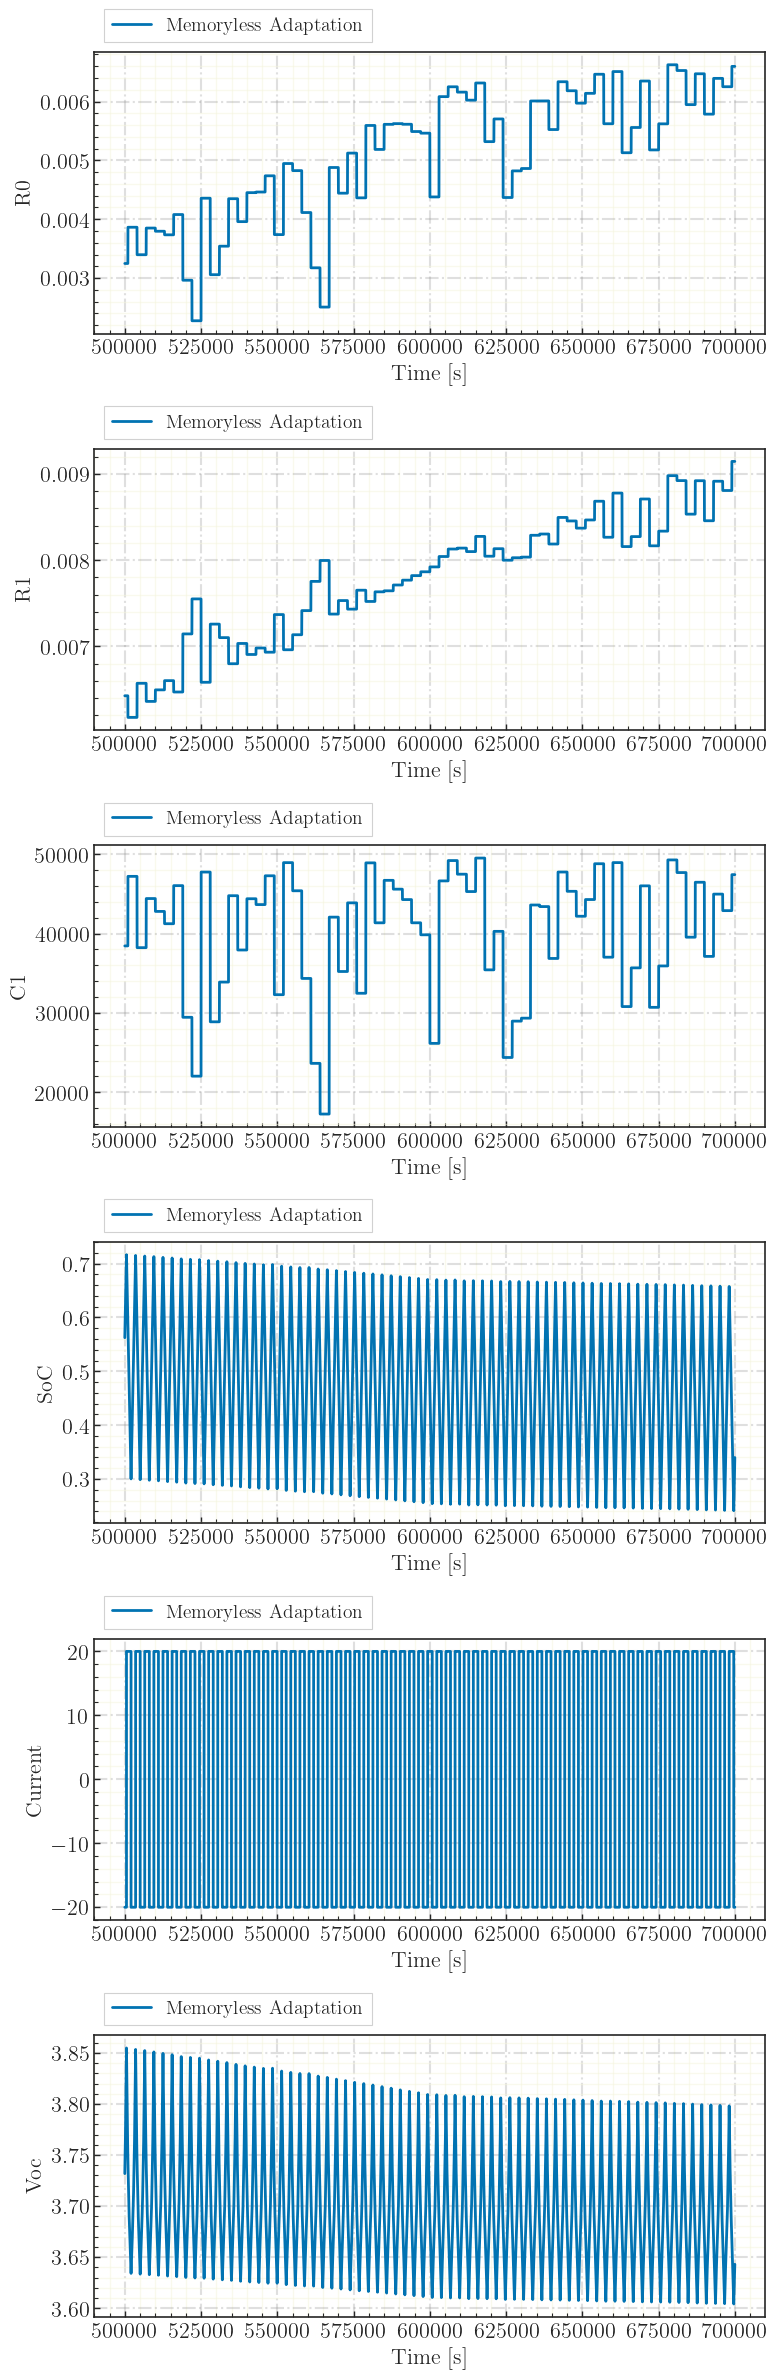

In [28]:
ernesto_plotter(**single_params)

## Plotting the evolution of parameters for EvolovingClustering method

In [281]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import numpy as np

def static_plot3d(X: pd.DataFrame, 
                             params: list, 
                             original: pd.DataFrame, 
                             faulty_clusters: dict):
    """
    Static 3D visualization of adaptive clustering (Matplotlib version).
    Replicates the final frame of the Plotly animation with publication styling.
    """
    # Extract parameters for readability
    x_col, y_col, z_col = params

    fig = plt.figure(figsize=(12, 10), dpi=120)
    ax = fig.add_subplot(111, projection='3d')

    # Remove gray panes for a clean look
    ax.xaxis.pane.fill = True
    ax.yaxis.pane.fill = True
    ax.zaxis.pane.fill = True
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')

    # --- 2. Plot Logic ---

    # A. Nominal Reference Cluster (Background)
    # Using 'original' dataframe
    if not original.empty:
        ax.scatter(
            original[x_col], 
            original[y_col], 
            original[z_col],
            color='blue',
            label=r'Nominal $\Theta_0$',
            s=15,
            alpha=1,            # Very faint to serve as background context
            edgecolors='none'
        )

    # B. Inliers (from current evolution X)
    # Logic: is_outlier == False AND active_cluster == 'nominal_temp_40'
    inliers = X[(X['is_outlier'] == False) & (X['active_cluster'] == 'nominal_temp_40')]
    if not inliers.empty:
        ax.scatter(
            inliers[x_col], 
            inliers[y_col], 
            inliers[z_col],
            color='blue',
            label='Inliers',
            s=20,
            alpha=0.4,
            edgecolors='none'
        )

    # C. Faulty Clusters (Iterate through dictionary)
    # Colors matching your Plotly snippet
    colors = ['green', 'orange', 'purple', 'violet', 'magenta', 'lime']
    
    # We need to collect times to filter 'pure' outliers later
    faulty_times = []

    for i, (key, fc_df) in enumerate(faulty_clusters.items()):
        faulty_times.extend(fc_df['time'].tolist())
        
        # Cycle through colors if there are more clusters than colors
        c = colors[i % len(colors)]
        
        ax.scatter(
            fc_df[x_col],
            fc_df[y_col],
            fc_df[z_col],
            color=c,
            label=fr'$\Theta_{i+1}$',
            s=40,
            alpha=0.8,
            edgecolors='white',    # White edge to pop
            linewidth=0.5
        )

    # D. Unassigned Outliers
    # Logic: is_outlier == True AND time NOT in faulty_times
    # (i.e., points that were flagged as outliers but didn't form a stable cluster)
    outliers = X[(X['is_outlier'] == True) & (~X['time'].isin(faulty_times))]
    
    if not outliers.empty:
        ax.scatter(
            outliers[x_col],
            outliers[y_col],
            outliers[z_col],
            color='red',
            label='Unassigned Outliers',
            s=25,
            marker='x',            # distinct marker for noise
            alpha=0.6,
            linewidth=1.0
        )

    # --- 4. Labels and View ---
    ax.set_xlabel(r'$R_0 \, [\Omega]$', labelpad=10, fontsize=16, fontweight='bold')
    ax.set_ylabel(r'$R_1 \, [\Omega]$', labelpad=10, fontsize=16, fontweight='bold')
    ax.set_zlabel(r'$C_1 \, [F]$', fontsize=16, labelpad=10, fontweight='bold')

    # Increase the padding of the tick numbers themselves so they don't touch the axis line
    ax.tick_params(axis='z', which='major', pad=8, labelsize=14) 
    ax.tick_params(axis='x', which='major', labelsize=14)
    ax.tick_params(axis='y', which='major', labelsize=14)
    
    # Adjust view angle for best perspective (Adjust these numbers to rotate the plot)
    ax.view_init(elev=25, azim=135)
    
    # Legend
    ax.legend(
        frameon=True, 
        fancybox=True, 
        framealpha=0.5, 
        edgecolor='black',
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.9), 
        fontsize=18,
        handletextpad=0.1
    )
    
    plt.tight_layout()
    #plt.savefig(plot_folder + f'OL-{exp_type}_tj{'-validation' if is_validation else ''}-cluster-evolution3D.png')

    plt.show()

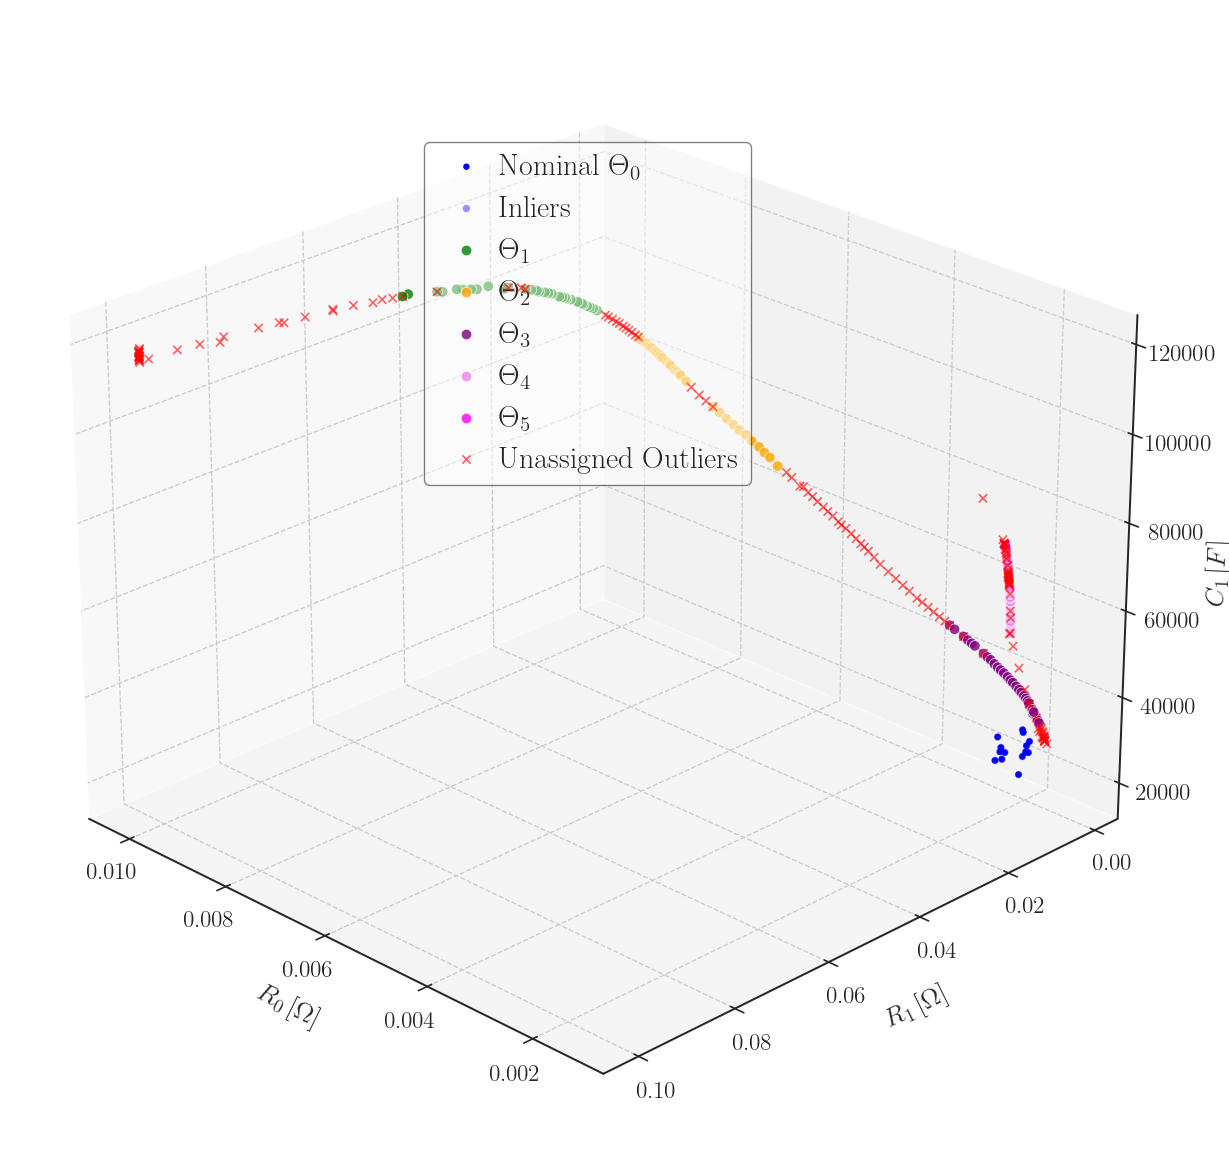

In [282]:
static_plot3d(
    X=df_samples,
    params=["r0", "r1", "c1"],
    original=df_samples[df_samples['time'] == 0],
    faulty_clusters={key: df for key, df in dfs_clusters.items() if 'nominal' not in key}
)

In [457]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def static_params_over_time(X: pd.DataFrame, 
                            params: list, 
                            original: pd.DataFrame, 
                            faulty_clusters: dict):
    """
    Static 2D visualization of parameter evolution over time (Matplotlib version).
    Creates stacked subplots for each parameter with publication styling.
    """
    window_size = 3000
    
    # Create subplots: One row per parameter, sharing the X-axis (Time)
    fig, axes = plt.subplots(
        nrows=len(params), 
        ncols=1, 
        figsize=(8, 2.5 * len(params)), # Adjust height dynamically
        sharex=True, 
        dpi=120
    )
    
    param_names = [r'$R_0 \,[\Omega]$', r'$R_1 \,[\Omega]$', r'$C_1 \,[F]$']
    
    # Ensure axes is always a list (even if only 1 param)
    if len(params) == 1:
        axes = [axes]

    # C. Faulty Clusters (Iterate through dictionary)
    # Colors matching your Plotly snippet
    colors = ['green', 'orange', 'purple', 'violet', 'magenta', 'lime']
    

    # --- 2. Iterate over each Parameter ---
    for idx, param in enumerate(params):
        ax = axes[idx]
        
        # A. Plot Nominal Reference (Background)
        if not original.empty and param in original.columns:
            ax.scatter(
                original["time"] * window_size, 
                original[param], 
                c='blue', 
                s=10, 
                alpha=1, 
                label=r'Nominal $\Theta_0$' if idx == 0 else "_nolegend_",
                edgecolors='none'
            )

        # B. Plot Inliers (Current Evolution)
        # Logic: is_outlier == False AND active_cluster == 'nominal_temp_40'
        inliers = X[(X['is_outlier'] == False) & (X['active_cluster'] == 'nominal_temp_40')]
        if not inliers.empty and param in inliers.columns:
            ax.scatter(
                inliers["time"] * window_size, 
                inliers[param], 
                c='blue', 
                s=15, 
                alpha=0.4, 
                label='Inliers' if idx == 0 else "_nolegend_",
                edgecolors='none'
            )

        # C. Plot Faulty Clusters
        faulty_times = []
        for i, (key, df) in enumerate(faulty_clusters.items()):
            if param in df.columns:
                ax.axvline(x=df_samples[df_samples['active_cluster'] == key]['time'].iloc[0] * window_size, color='red',  linestyle='--', linewidth=1)
                faulty_times.extend(df['time'].tolist())
                
                # Pick unique color
                c = colors[i % len(colors)]
                
                ax.scatter(
                    df["time"] * window_size,
                    df[param],
                    color=c,
                    s=25,
                    alpha=0.8,
                    label=fr'$\Theta_{i+1}$',
                    edgecolors='white',
                    linewidth=0.5
                )

        # D. Plot Unassigned Outliers
        # Logic: Outliers that are NOT part of a known faulty cluster yet
        outliers = X[(X['is_outlier'] == True) & (~X['time'].isin(faulty_times))]
        if not outliers.empty and param in outliers.columns:
            ax.scatter(
                outliers["time"] * window_size,
                outliers[param],
                c='red',
                marker='x',
                s=20,
                alpha=0.6,
                label='Unassigned Outliers' if idx == 0 else "_nolegend_"
            )

        # Labels & Formatting per subplot
        ax.set_ylabel(param_names[idx], fontweight='bold', fontsize=16, labelpad=10)
        
        # Increase the padding of the tick numbers themselves so they don't touch the axis line
        ax.tick_params(axis='x', which='major', labelsize=14)
        ax.tick_params(axis='y', which='major', labelsize=14)
        
        # Remove top/right spines for cleaner look
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # --- 3. Final Layout Touches ---
    
    # Only set X-label on the bottom-most plot
    axes[-1].set_xlabel(r"Time $[s]$", fontweight='bold', labelpad=10)

    # Unified Legend (collected from the first subplot)
    # We place it above the top subplot
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='upper center', 
        fontsize=16,
        bbox_to_anchor=(0.5, 0.95), 
        ncol=4, 
        frameon=True,
        fancybox=True,
        handletextpad=0.01,
        columnspacing=0.7,
        markerscale=1.5
    )

    # Adjust layout to make room for title and legend
    plt.tight_layout(rect=[0, 0, 1, 0.88]) 
    #plt.savefig(plot_folder + f'OL-{exp_type}_tj{'_validation' if is_validation else ''}-cluster-evolution-over-time.png')
    plt.show()

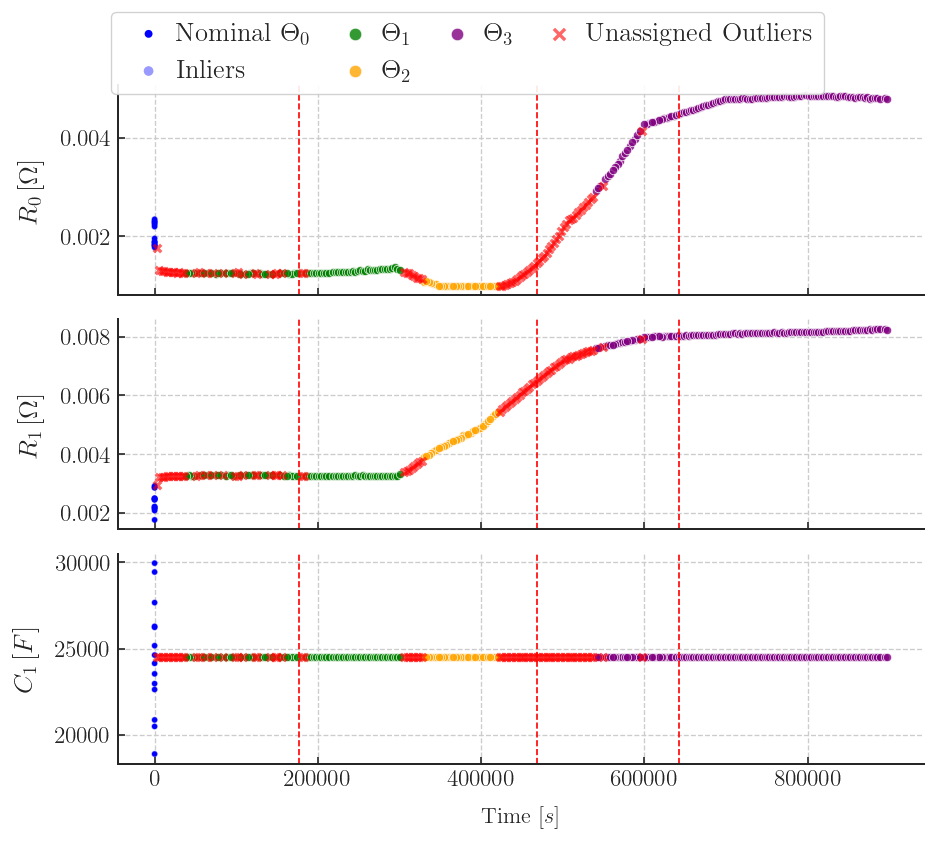

In [458]:
static_params_over_time(
    X=df_samples,
    params=["r0", "r1", "c1"],
    original=df_samples[df_samples['time'] == 0],
    faulty_clusters={key: df for key, df in sorted(dfs_clusters.items()) if 'nominal' not in key}
)